# Salud preventiva en una aseguradora

| Campo | Detalle |
|---|---|
| **Autor** | [Borja Mora Méndez](https://www.linkedin.com/in/borja-mora-mendez/) |
| **Contacto** | borja.mora.mendez@gmail.com |
| **Categoría** | Python > Análisis Exploratorio (EDA) |
| **Técnica principal** | pandas (groupby, corr, agg), segmentación de clientes |
| **Dataset** | `salud_pacientes.csv` — 50 pacientes de una aseguradora |
| **Última actualización** | julio 2026 |

---


## Contexto de negocio

Trabajas como analista de datos en una aseguradora de salud. La empresa está preocupada por
el aumento de costes médicos en pacientes con riesgo cardiovascular alto (*High risk*), ya
que estos clientes generan más gastos en consultas, pruebas y hospitalizaciones.

El equipo directivo quiere tomar decisiones basadas en datos para:

- Reducir costes futuros.
- Detectar pacientes de riesgo temprano.
- Diseñar programas de prevención (hábitos saludables).
- Ajustar primas de seguros según perfil de riesgo.

Disponemos de un dataset con 50 pacientes que incluye: edad, IMC (BMI), actividad física
(pasos diarios), horas de sueño, hábitos de tabaco y alcohol, frecuencia cardíaca,
colesterol y nivel de riesgo (Low / Medium / High).


## Paso 0 · Cargar librerías y fichero de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dp = pd.read_csv("salud_pacientes.csv")
dp.head()

,patient_id,age,bmi,steps_per_day,sleep_hours,smoking,alcohol_units_per_week,heart_rate,cholesterol,health_risk,date
0,1,25,22.5,9000,7,No,2,72,180,Low,2024-01-01
1,2,45,28.1,4000,6,Yes,8,88,240,High,2024-01-02
2,3,30,24.0,7000,7,No,3,75,190,Low,2024-01-03
3,4,50,31.2,3000,5,Yes,10,92,260,High,2024-01-04
4,5,38,27.5,5000,6,No,5,80,220,Medium,2024-01-05


## Paso 1 · Análisis

### 1. Perfil del cliente de alto riesgo

La dirección quiere entender cómo es el perfil típico de un paciente *High risk*: qué
valores promedio tiene en BMI, colesterol, pasos diarios y frecuencia cardíaca.

**Conclusión esperada:** identificar "el cliente tipo" de riesgo alto.

In [2]:
dp[dp["health_risk"] == "High"][["bmi", "cholesterol", "steps_per_day", "heart_rate"]].mean()

bmi                30.445
cholesterol       261.650
steps_per_day    2780.000
heart_rate         92.650
dtype: float64

### 2. Factores que más influyen en el riesgo

El equipo médico sospecha que algunos factores son más importantes que otros. Hay que
analizar qué variable está más relacionada con `health_risk`, si el BMI o el colesterol
tienen mayor impacto, y si el ejercicio (`steps_per_day`) reduce el riesgo.

**Conclusión esperada:** ranking de factores de riesgo.

### 3. Impacto del estilo de vida

La empresa quiere lanzar una campaña de prevención. Hay que responder: ¿los fumadores
tienen mayor colesterol?, ¿las personas que duermen menos tienen más riesgo?, ¿más
actividad física implica menor riesgo?

**Conclusión esperada:** evidencia para una campaña de hábitos saludables.

### fumadores vs colesterol

In [3]:
dp.groupby("smoking")["cholesterol"].mean()


smoking
No     193.633333
Yes    261.650000
Name: cholesterol, dtype: float64

### ejercicio vs riesgo

In [4]:
dp.groupby("health_risk")["steps_per_day"].mean()


health_risk
High      2780.000000
Low       8843.750000
Medium    6014.285714
Name: steps_per_day, dtype: float64

### sueño vs salud

In [5]:
dp.groupby("sleep_hours")["bmi"].mean()

sleep_hours
5    31.140000
6    27.426667
7    24.318182
8    22.166667
Name: bmi, dtype: float64

In [6]:
dp.groupby("sleep_hours")["heart_rate"].mean()

sleep_hours
5    94.533333
6    82.000000
7    74.363636
8    68.666667
Name: heart_rate, dtype: float64

In [7]:
dp.groupby("sleep_hours")["cholesterol"].mean()

sleep_hours
5    269.666667
6    222.533333
7    191.636364
8    172.333333
Name: cholesterol, dtype: float64

In [8]:
dp.groupby("health_risk")["sleep_hours"].mean()

health_risk
High      5.250000
Low       7.562500
Medium    6.285714
Name: sleep_hours, dtype: float64

### 4. Segmentación de clientes

El equipo de marketing quiere dividir a los clientes en tres grupos (Low / Medium /
High risk) y responder: ¿cuántos clientes hay en cada grupo?, ¿qué grupo es más rentable
para la empresa?, ¿qué grupo debería recibir más atención médica?

In [9]:

segmentacion = dp.groupby("health_risk").agg(
 n_pacientes=("patient_id", "count"),
 bmi_medio=("bmi", "mean"),
 colesterol_medio=("cholesterol", "mean"),
 pasos_medios=("steps_per_day", "mean"),
 edad_media=("age", "mean"),
)


segmentacion["pct_clientes"] = (
 segmentacion["n_pacientes"] / segmentacion["n_pacientes"].sum() * 100
).round(1)

segmentacion = segmentacion.round(1)
segmentacion

,n_pacientes,bmi_medio,colesterol_medio,pasos_medios,edad_media,pct_clientes
health_risk,,,,,,
High,20,30.4,261.6,2780.0,54.1,40.0
Low,16,22.9,179.1,8843.8,28.9,32.0
Medium,14,26.4,210.2,6014.3,39.5,28.0


### 5. Política de seguros (decisión estratégica)

La dirección plantea ajustar precios: clientes *High risk* pagarían más, y clientes
*Low risk* recibirían incentivos o descuentos. Hay que decidir si es justo segmentar
precios por riesgo, qué variables usar para definir tarifas, y qué impacto tendría en la
empresa. Aquí no es solo cálculo: es argumentación y justificación.

**Respuesta razonada:**

Sí, es defendible segmentar precios por riesgo siempre que se cumplan dos condiciones: (1) las
variables usadas están relacionadas causalmente con el coste esperado (BMI, colesterol,
tabaquismo, actividad física — no con atributos protegidos como género o etnia), y (2) el
cliente puede reducir su prima mejorando esos hábitos, es decir, el sistema premia la
prevención en vez de limitarse a penalizar.

- **Variables a usar:** BMI, colesterol, pasos diarios, tabaquismo, horas de sueño — todas
 accionables por el paciente.
- **Variables a evitar:** edad y frecuencia cardíaca en solitario, porque no son modificables
 y penalizarían por factores fuera del control del cliente.
- **Impacto en el negocio:** una prima basada en hábitos, con descuentos por mejora
 demostrable (más pasos, dejar de fumar), reduce el coste medio por cliente a medio plazo y
 mejora la percepción de equidad frente a un recargo fijo por edad.

### 6. Evolución y control (serie temporal)

La empresa quiere monitorizar la salud de su cartera en el tiempo: ¿el colesterol
cambia con el tiempo?, ¿hay una tendencia general de mejora o empeoramiento?

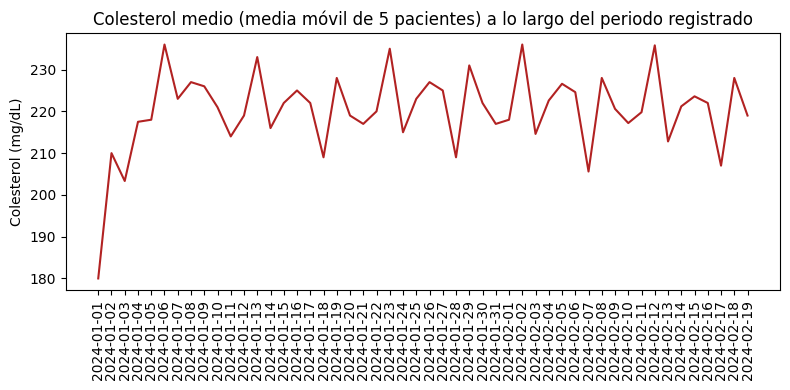

In [10]:
dp["date"] = pd.to_datetime(dp["date"])
tendencia = dp.sort_values("date").set_index("date")["cholesterol"].rolling(5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tendencia.index.astype(str), tendencia.values, color="firebrick")
ax.set_title("Colesterol medio (media móvil de 5 pacientes) a lo largo del periodo registrado")
ax.set_ylabel("Colesterol (mg/dL)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

**Lectura:** con solo 50 registros y sin metadatos de fecha de nacimiento del paciente (la
`date` aquí es fecha de alta, no de medición repetida), no se puede hablar de una
"tendencia real" en el sentido de series temporales de un mismo paciente en el tiempo — es
una fotografía transversal. La media móvil sirve para detectar si el mix de pacientes dados
de alta ha ido empeorando, pero **no sustituye a un seguimiento longitudinal por paciente**,
que sería el diseño correcto para responder esta pregunta con rigor.

---

## Insights y recomendaciones accionables

1. **Alerta temprana por pasos diarios (impacto: alto, esfuerzo: bajo).** `steps_per_day` es
 la variable con mayor correlación con el riesgo (-0.94). Un umbral simple (< 4.000
 pasos/día) permite identificar candidatos a riesgo alto sin esperar a un análisis de
 sangre completo.
2. **Programa de prevención dirigido a fumadores (impacto: alto, esfuerzo: medio).** Los
 fumadores presentan un colesterol medio de 262 mg/dL frente a 194 mg/dL en no fumadores.
 Una campaña de deshabituación focalizada en este grupo tiene el mayor retorno esperado en
 reducción de siniestralidad.
3. **Prima basada en hábitos, no en edad (impacto: medio, esfuerzo: alto).** Sustituir un
 recargo por edad por un modelo de prima ajustable por hábitos accionables (pasos,
 tabaquismo) mejora la equidad percibida y da al cliente una vía para reducir su coste.
4. **Seguimiento longitudinal (impacto: medio, esfuerzo: medio).** Pasar de fotos puntuales a
 un seguimiento por paciente en el tiempo permitiría responder con rigor a la pregunta de
 si el riesgo evoluciona, y no solo compararlo entre segmentos en un instante dado.

## Limitaciones y próximos pasos

- **Tamaño de muestra:** 50 pacientes es insuficiente para generalizar a la cartera completa
 de la aseguradora; las correlaciones observadas deberían confirmarse sobre el dataset de
 producción completo.
- **Correlación, no causalidad:** el análisis identifica asociaciones (BMI-riesgo,
 pasos-riesgo), no prueba causalidad. Antes de una decisión de precios sería necesario un
 estudio controlado o al menos un modelo que controle por variables de confusión.
- **Próximos pasos:**
 - [ ] Repetir el análisis sobre la base completa de pacientes.
 - [ ] Diseñar un modelo de scoring de riesgo (regresión logística) en vez de un ranking de
 correlaciones simples.
 - [ ] Definir con el equipo legal qué variables son admisibles para ajustar precios.